In [149]:
import numpy as np

In [150]:
class KMeans():
    def __init__(self, clusters: int=2, iter: int=100):
        self.clusters = clusters;
        self.cluster_pos = None;
        self.X = None;
        self.iter = iter;
    
    def distance(self, X, Xt) -> np.float32:
        return np.sqrt(np.sum((X - Xt)**2))
    
    def fit(self, X: np.ndarray):
        
        if(self.cluster_pos == None):
            self.X = X;
            self.cluster_pos = np.random.randint(0, 4, (self.clusters, X.shape[1]))

            print("Init: ");
            print(self.cluster_pos)
        
        while(self.iter):
            self.cluster_asigments = [[] for i in range(self.clusters)]

            print("-------")
            for point in self.X:
                cluster_asign = -1;
                dist_to_cluster = [self.distance(point, x) for x in self.cluster_pos];
                # print("Dist: ", dist_to_cluster)
                cluster_asign = np.argmin(dist_to_cluster)
                # print("Cluter Asig: ", cluster_asign)
                self.cluster_asigments[cluster_asign].append(point)

            cluster_pos_new = []

            for cent_asign in self.cluster_asigments:
                if cent_asign:
                    cluster_pos_new.append(np.mean(cent_asign, axis=0))
                else:
                    cluster_pos_new.append(np.random.randint(0, 4, X.shape[1]))            
            print(cluster_pos_new)

            self.cluster_pos = np.array(cluster_pos_new)

            self.iter -= 1;

    def predict(self, X: np.ndarray) -> np.ndarray:
        pred = []
        for point in X:
            cluster_asign = -1;
            dist_to_cluster = [self.distance(point, x) for x in self.cluster_pos];
            cluster_asign = np.argmin(dist_to_cluster)
            pred.append(cluster_asign)
        return np.array(pred)


In [151]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=0)

In [152]:
model = KMeans(3, iter=10000)
model.fit(X)

Init: 
[[3 1]
 [1 0]
 [1 2]]
-------
[array([2.89052115, 0.96152082]), array([1.33979017, 0.06990554]), array([-0.20079474,  3.47701703])]
-------
[array([2.7566401 , 1.22374746]), array([1.30956043, 0.33759897]), array([-0.3696174 ,  3.63376944])]
-------
[array([2.69434046, 1.40550073]), array([1.29935484, 0.38527467]), array([-0.43474997,  3.66605547])]
-------
[array([2.64923545, 1.54877498]), array([1.34025439, 0.35023139]), array([-0.46675771,  3.67336162])]
-------
[array([2.62359055, 1.61785622]), array([1.38196089, 0.32082166]), array([-0.48381251,  3.66787836])]
-------
[array([2.60300692, 1.73225623]), array([1.43043835, 0.30960887]), array([-0.50984839,  3.66208937])]
-------
[array([2.55221523, 1.86854554]), array([1.51234311, 0.28234891]), array([-0.54272333,  3.65322727])]
-------
[array([2.47909398, 2.08120375]), array([1.63008155, 0.27558202]), array([-0.58826901,  3.64393265])]
-------
[array([2.35006996, 2.43299452]), array([1.776398  , 0.30985543]), array([-0.672156

KeyboardInterrupt: 

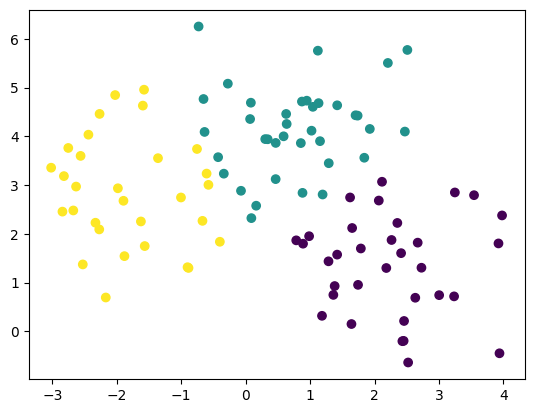

In [ ]:
import matplotlib.pyplot as plt

y = model.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y)